# Research feature added

In [477]:
from __future__ import annotations

import operator
from typing import TypedDict,List,Annotated,Literal,Optional
from pathlib import Path
from dotenv import load_dotenv

from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send

from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_core.prompt_values import ChatPromptValue
from langchain_core.output_parsers import PydanticOutputParser
from langchain_classic.output_parsers import OutputFixingParser,RetryWithErrorOutputParser
from langchain_community.tools.tavily_search import TavilySearchResults

In [478]:
load_dotenv()

True

In [479]:
class Task(BaseModel):
    id:int
    title:str
    goal:str=Field(
        description="One sentence describing what the reader should be able to do/understand after this section."
    )
    bullets:List[str]=Field(
        min_length=0,
        max_length=5,
        description="Upto 5 concrete, non-overlapping subpoints to cover in this section."
    )
    target_words:int=Field(
        description="Target word count for this section (120-450)."
    )
    # section_type:Literal[
    #     "intro","core","examples","checklist","common_mistakes","conclusion"
    # ]=Field(
    #     description="Use 'common_mistakes' exactly once in the plan."
    # )
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False
    # brief:str=Field(
    #     description="what to cover"
    # )

In [480]:
class Plan(BaseModel):
    blog_title:str
    audience:str=Field(description="Who this blog is for.")
    tone:str=Field(description="Writing tone (e.g., practical, crisp).")
    blog_kind:Literal["explainer","tutorial", "news_roundup", "comparison", "system_design"]="explainer"
    constraints:List[str]=Field(default_factory=list)
    tasks:list[Task]

In [481]:
class EvidenceItem(BaseModel):
    title:str
    url:str
    published_at:Optional[str]=None
    snippet:Optional[str]=None
    source:Optional[str]=None

In [482]:
class EvidencePack(BaseModel):
    evidence:List[EvidenceItem]=Field(default_factory=list)

In [483]:
class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)

In [484]:
class State(TypedDict):
    topic:str
    plan:Optional[Plan]
    sections:Annotated[List[str],operator.add]
    result:str
    mode:str
    need_research:bool
    queries:List[str]
    evidence:List[EvidenceItem]
    


In [485]:
# Yeh setup top par rakho
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Meta-Llama-3-8B-Instruct",  # Model change karna zaruri hai
    task="text-generation",
    max_new_tokens=2500,
    temperature=0.1
)

model = ChatHuggingFace(llm=llm)
parser = PydanticOutputParser(pydantic_object=Plan)
retry_parser = RetryWithErrorOutputParser.from_llm(parser=parser, llm=model)

In [486]:
# -----------------------------
# 3) Router (decide upfront)
# -----------------------------
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3-10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""


In [487]:
router_parser = PydanticOutputParser(
    pydantic_object=RouterDecision
)

router_retry_parser = RetryWithErrorOutputParser.from_llm(
    parser=router_parser,
    llm=model
)

import json
import re

def router(state: State) -> dict:
    topic = state["topic"]

    prompt_value = ChatPromptValue(
        messages=[
            SystemMessage(
                content=f"""
{ROUTER_SYSTEM}

CRITICAL RULES:
- Return ONLY a JSON object.
- No markdown.
- No explanations.
- No text before JSON.
- No text after JSON.

Example:

{{
  "needs_research": true,
  "mode": "hybrid",
  "queries": [
    "latest multimodal llm benchmarks 2026",
    "state of multimodal llms 2026"
  ]
}}
"""
            ),
            HumanMessage(
                content=f"Topic: {topic}"
            )
        ]
    )

    response = model.invoke(prompt_value)

    raw = (
        response.content
        if isinstance(response.content, str)
        else str(response.content)
    ).strip()

    try:
        decision = router_parser.parse(raw)

    except Exception as first_error:

        try:
            decision = router_retry_parser.parse_with_prompt(
                raw,
                prompt_value
            )

        except Exception:

            match = re.search(
                r"\{.*\}",
                raw,
                re.DOTALL
            )

            if not match:
                raise ValueError(
                    f"Could not find JSON in router output:\n{raw}"
                ) from first_error

            try:
                data = json.loads(match.group(0))
                decision = RouterDecision(**data)

            except Exception as json_error:
                raise ValueError(
                    f"Invalid router JSON:\n{raw}"
                ) from json_error

    return {
        "need_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

In [488]:

    # def router(state: State) -> dict:
    #     topic = state["topic"]

    #     prompt_value = ChatPromptValue(
    #         messages=[
    #             SystemMessage(
    #                 content=f"""
    # {ROUTER_SYSTEM}

    # Return ONLY valid JSON.

    # {router_parser.get_format_instructions()}
    # """
    #             ),
    #             HumanMessage(
    #                 content=f"Topic: {topic}"
    #             )
    #         ]
    #     )

    #     raw_response = model.invoke(prompt_value)

    #     try:
    #         decision = router_parser.parse(raw_response.content)
    #     except Exception:
    #         decision = router_retry_parser.parse_with_prompt(
    #             raw_response.content,
    #             prompt_value
    #         )

    #     return {
    #         "need_research": decision.needs_research,
    #         "mode": decision.mode,
    #         "queries": decision.queries,
    #     }

In [489]:
# def router_node(state: State) -> dict:
#     format_instructions = router_parser.get_format_instructions()

#     messages = [
#         SystemMessage(
#             content=(
#                 ROUTER_SYSTEM
#                 + "\n\nIMPORTANT:\n"
#                 + "Return ONLY valid JSON.\n"
#                 + "Do not explain your answer.\n"
#                 + "Do not use markdown.\n"
#                 + "Do not add text before or after the JSON.\n\n"
#                 + format_instructions
#             )
#         ),
#         HumanMessage(
#             content=f"Topic: {state['topic']}"
#         ),
#     ]

#     response = model.invoke(messages)

#     text = response.content.strip()

#     if text.startswith("```"):
#         text = text.replace("```json", "")
#         text = text.replace("```", "")
#         text = text.strip()

#     try:
#         route = router_parser.parse(text)

#     except Exception:
#         import re

#         match = re.search(r"\{.*\}", text, re.DOTALL)

#         if not match:
#             raise ValueError(
#                 f"Model did not return JSON.\nRaw output:\n{text}"
#             )

#         route = router_parser.parse(match.group(0))

#     return {"route": route}

In [490]:
def router_next(state:State)->str:
    return "research" if state["need_research"] else "orchestrator"

In [491]:
# def tavily_search(query:str,max_result:int=5)->List[dict]:
#     tool=TavilySearchResults(max_results=max_result)
#     results=tool.invoke({"query":query})

#     normalized:List[dict]=[]

#     for i in results or[]:
#         normalized.append(
#             {
#                 "title": i.get("title") or "",
#                 "url": i.get("url") or "",
#                 "snippet": i.get("content") or i.get("snippet") or "",
#                 "published_at": i.get("published_date") or i.get("published_at"),
#                 "source": i.get("source"),
#             }
#         )

#         return normalized
        

In [492]:
def tavily_search(query: str, max_result: int = 5) -> List[dict]:
    tool = TavilySearchResults(max_results=max_result)

    try:
        results = tool.invoke({"query": query})
    except Exception:
        return []

    normalized: List[dict] = []

    for i in results or []:
        normalized.append(
            {
                "title": i.get("title") or "",
                "url": i.get("url") or "",
                "snippet": i.get("content") or i.get("snippet") or "",
                "published_at": i.get("published_date") or i.get("published_at"),
                "source": i.get("source"),
            }
        )

    return normalized

In [493]:
# def tavily_search(query: str, max_result: int = 5) -> List[dict]:
#     tool = TavilySearchResults(max_results=max_result)
#     results = tool.invoke({"query": query})

#     normalized = []

#     for i in results or []:
#         normalized.append(
#             {
#                 "title": i.get("title") or "",
#                 "url": i.get("url") or "",
#                 "snippet": i.get("content") or i.get("snippet") or "",
#                 "published_at": i.get("published_date") or i.get("published_at"),
#                 "source": i.get("source"),
#             }
#         )

#     return normalized

In [494]:
RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

In [495]:
research_parser = PydanticOutputParser(
    pydantic_object=EvidencePack
)

research_retry_parser = RetryWithErrorOutputParser.from_llm(
    parser=research_parser,
    llm=model
)

In [496]:
def research_node(state: State) -> dict:
    queries = state.get("queries", []) or []

    raw_results = []

    # Keep search volume reasonable
    for q in queries[:4]:
        raw_results.extend(
            tavily_search(q, 3)
        )

    if not raw_results:
        return {
            "evidence": []
        }

    evidence = []
    seen_urls = set()

    for item in raw_results:

        url = item.get("url")

        if not url:
            continue

        if url in seen_urls:
            continue

        seen_urls.add(url)

        evidence.append(
            EvidenceItem(
                title=item.get("title", ""),
                url=url,
                snippet=item.get("snippet"),
                published_at=item.get("published_at"),
                source=item.get("source"),
            )
        )

    return {
        "evidence": evidence[:20]
    }

In [497]:

# -----------------------------
# 5) Orchestrator (Plan)
# -----------------------------
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5-9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3-6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120-550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

In [498]:
plan_parser = PydanticOutputParser(
    pydantic_object=Plan
)

plan_retry_parser = RetryWithErrorOutputParser.from_llm(
    parser=plan_parser,
    llm=model
)

In [499]:
def orchestrator_node(state: State) -> dict:
    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    response = model.invoke(
        [
            SystemMessage(
                content=(
                    ORCH_SYSTEM
                    + "\n\n"
                    + plan_parser.get_format_instructions()
                )
            ),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n\n"
                    f"Evidence:\n"
                    f"{[e.model_dump() for e in evidence][:16]}"
                )
            ),
        ]
    )

    plan = plan_parser.parse(response.content)

    return {"plan": plan}

In [500]:
# def orchestrator_node(state: State) -> dict:
#     evidence = state.get("evidence", [])
#     mode = state.get("mode", "closed_book")

#     format_instructions = plan_parser.get_format_instructions()

#     prompt = [
#         SystemMessage(
#             content=(
#                 ORCH_SYSTEM
#                 + "\n\n"
#                 + format_instructions
#             )
#         ),
#         HumanMessage(
#             content=(
#                 f"Topic: {state['topic']}\n"
#                 f"Mode: {mode}\n\n"
#                 f"Evidence (ONLY use for fresh claims; may be empty):\n"
#                 f"{[e.model_dump() for e in evidence][:16]}"
#             )
#         ),
#     ]

#     response = model.invoke(prompt)

#     try:
#         plan = plan_parser.parse(response.content)

#     except Exception:
#         plan = plan_retry_parser.parse_with_prompt(
#             completion=response.content,
#             prompt=prompt
#         )

#     return {"plan": plan}

In [501]:
# def orchestrator_node(state: State) -> dict:
#     planner = llm.with_structured_output(Plan)

#     evidence = state.get("evidence", [])
#     mode = state.get("mode", "closed_book")

#     plan = planner.invoke(
#         [
#             SystemMessage(content=ORCH_SYSTEM),
#             HumanMessage(
#                 content=(
#                     f"Topic: {state['topic']}\n"
#                     f"Mode: {mode}\n\n"
#                     f"Evidence (ONLY use for fresh claims; may be empty):\n"
#                     f"{[e.model_dump() for e in evidence][:16]}"
#                 )
#             ),
#         ]
#     )

#     return {"plan": plan}

In [502]:
# def orchestrator_node(state: State) -> dict:
#     evidence = state.get("evidence", [])
#     mode = state.get("mode", "closed_book")

#     evidence_text = "\n".join(
#         [
#             f"- {e.title} | {e.url}"
#             for e in evidence[:10]
#         ]
#     )

#     prompt = f"""
# {ORCH_SYSTEM}

# Topic: {state['topic']}
# Mode: {mode}

# Evidence:
# {evidence_text}

# Return ONLY valid JSON matching this structure:

# {{
#   "blog_title": "string",
#   "audience": "string",
#   "tone": "string",
#   "blog_kind": "explainer",
#   "constraints": [],
#   "tasks": [
#     {{
#       "id": 1,
#       "title": "string",
#       "goal": "string",
#       "bullets": ["a", "b", "c"],
#       "target_words": 250,
#       "section_type": "intro",
#       "tags": [],
#       "requires_research": false,
#       "requires_citations": false,
#       "requires_code": false
#     }}
#   ]
# }}

# Do not use markdown.
# Do not use ```json.
# Do not explain.
# Output only JSON.
# """

#     try:
#         response = model.invoke(prompt)

#         print("===== ORCHESTRATOR RAW =====")
#         print(response.content)
#         print("============================")
#     import json
# import re

# raw = response.content.strip()

# # Remove markdown fences if model adds them
# raw = raw.replace("```json", "")
# raw = raw.replace("```", "")
# raw = raw.strip()

# match = re.search(r"\{.*\}", raw, re.DOTALL)

# if not match:
#     raise ValueError(f"No JSON found in output:\n{raw}")

# json_text = match.group(0)

# plan_dict = json.loads(json_text)

# plan = Plan(**plan_dict)

#         return {
#             "plan": plan
#         }

#     except Exception as e:
#         print("===== ORCHESTRATOR FAILED =====")
#         print(e)
#         print("===============================")
#         raise

In [503]:
# def orchestrator_node(state: State) -> dict:
#     import json
#     import re

#     evidence = state.get("evidence", [])
#     mode = state.get("mode", "closed_book")

#     evidence_text = "\n".join(
#         [
#             f"- {e.title} | {e.url}"
#             for e in evidence[:10]
#         ]
#     )

#     prompt = f"""
# {ORCH_SYSTEM}

# Topic: {state['topic']}
# Mode: {mode}

# Evidence:
# {evidence_text}

# Return ONLY valid JSON matching this structure:

# {{
#   "blog_title": "string",
#   "audience": "string",
#   "tone": "string",
#   "blog_kind": "explainer",
#   "constraints": [],
#   "tasks": [
#     {{
#       "id": 1,
#       "title": "string",
#       "goal": "string",
#       "bullets": ["a", "b", "c"],
#       "target_words": 250,
#       "section_type": "intro",
#       "tags": [],
#       "requires_research": false,
#       "requires_citations": false,
#       "requires_code": false
#     }}
#   ]
# }}

# Do not use markdown.
# Do not use ```json.
# Do not explain.
# Output only JSON.
# """

#     try:
#         response = model.invoke(prompt)

#         print("===== ORCHESTRATOR RAW =====")
#         print(response.content)
#         print("============================")

#         raw = response.content.strip()

#         # Remove markdown fences if present
#         raw = raw.replace("```json", "")
#         raw = raw.replace("```", "")
#         raw = raw.strip()

#         # Extract first JSON object
#         match = re.search(r"\{.*\}", raw, re.DOTALL)

#         if not match:
#             raise ValueError(
#                 f"Could not find JSON in orchestrator output:\n{raw}"
#             )

#         json_text = match.group(0)

#         print("===== EXTRACTED JSON =====")
#         print(json_text[:1000])
#         print("==========================")

#         plan_dict = json.loads(json_text)

#         plan = Plan(**plan_dict)

#         return {
#             "plan": plan
#         }

#     except Exception as e:
#         print("===== ORCHESTRATOR FAILED =====")
#         print(e)
#         print("===============================")
#         raise

In [504]:
def no_of_worker(state:State):
    return [
        Send(
            "Worker",
            {
                "task":task.model_dump(),
                "topic":state["topic"],
                "plan":state["plan"].model_dump(),
                "mode":state["mode"],
                "evidence":[e.model_dump() for e in state.get("evidence",[])]
            },
        )
        for task in state["plan"].tasks
    ]

In [505]:
# -----------------------------
# 7) Worker (write one section)
# -----------------------------
WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""

def worker_node(payload: dict) -> dict:

    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]

    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}"
            for e in evidence[:20]
        )

    response = model.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n"
                    f"{evidence_text}\n"
                )
            ),
        ]
    )

    section_md = response.content.strip()

    return {
        "sections": [(task.id, section_md)]
    }

In [506]:
# -----------------------------
# 8) Reducer (merge + save)
# -----------------------------
def reducer_node(state: State) -> dict:

    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    filename = f"{plan.blog_title}.md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [507]:
# -----------------------------
# 9) Build graph
# -----------------------------
g = StateGraph(State)
g.add_node("router", router)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", router_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", no_of_worker, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

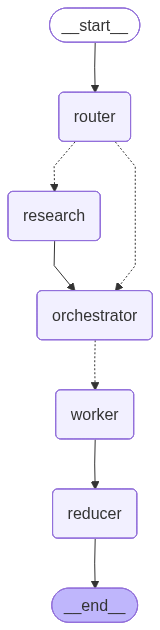

In [508]:
app

In [509]:

# -----------------------------
# 10) Runner
# -----------------------------
def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "need_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    return out

In [510]:
#run("Write a blog on Open Source LLMs in 2026")
run("State of Multimodal LLMs in 2026")

Ignoring unknown node name Worker in pending sends
Ignoring unknown node name Worker in pending sends
Ignoring unknown node name Worker in pending sends


{'topic': 'State of Multimodal LLMs in 2026',
 'plan': Plan(blog_title='State of Multimodal LLMs in 2026', audience='Developers', tone='Practical', blog_kind='explainer', constraints=[], tasks=[Task(id=1, title='Multimodal LLMs: The New Frontier', goal='Understand the current state of multimodal LLMs and their applications', bullets=['MiMo-V2.5-Pro: A hybrid attention mechanism for long-context tasks', 'Kimi-K2.6: A long-context, agent-oriented LLM for coding', 'Gemma 4: A unified model design for text, image, and audio'], target_words=250, tags=['multimodal', 'LLMs', 'AI'], requires_research=False, requires_citations=False, requires_code=False), Task(id=2, title='The Rise of Agentic AI', goal='Understand the concept of agentic AI and its applications', bullets=['Agentic AI: A new paradigm for AI development', 'Tool use and multi-step workflows in agentic AI', 'The Model Context Protocol (MCP) for tool and data access'], target_words=200, tags=['agentic', 'AI', 'tool use'], requires_re

In [511]:
run("Write a blog on Open Source LLMs in 2026")
# run("State of Multimodal LLMs in 2026")

Ignoring unknown node name Worker in pending sends
Ignoring unknown node name Worker in pending sends
Ignoring unknown node name Worker in pending sends
Ignoring unknown node name Worker in pending sends


{'topic': 'Write a blog on Open Source LLMs in 2026',
 'plan': Plan(blog_title='Open Source LLMs in 2026', audience='Developers', tone='Practical', blog_kind='explainer', constraints=[], tasks=[Task(id=1, title='Introduction to Open Source LLMs', goal='Understand the current state of open source LLMs in 2026', bullets=['Familiarize yourself with the top 7 open source LLMs in 2026', 'Learn about the key features and capabilities of each model', 'Understand the benefits and limitations of using open source LLMs'], target_words=250, tags=['open source LLMs', '2026', 'top 7 models'], requires_research=False, requires_citations=False, requires_code=False), Task(id=2, title="Qwen 3.5: Alibaba's Native Multimodal Agent", goal='Understand the capabilities and features of Qwen 3.5', bullets=['Learn about the architecture and design of Qwen 3.5', 'Understand the benefits and limitations of using Qwen 3.5 for multimodal tasks', 'Compare Qwen 3.5 with other open source LLMs'], target_words=300, ta

In [512]:
#run("Write a blog on Open Source LLMs in 2026")
run("Top news of this weak")

Ignoring unknown node name Worker in pending sends
Ignoring unknown node name Worker in pending sends
Ignoring unknown node name Worker in pending sends


{'topic': 'Top news of this weak',
 'plan': Plan(blog_title='Top News of the Week', audience='Developers', tone='Practical', blog_kind='news_roundup', constraints=[], tasks=[Task(id=1, title='Top Tech News', goal='Summarize the top tech news of the week', bullets=["Marvell Technology and Flex to join S&P 500 index, replacing Pool and Campbell's", 'Google to pay SpaceX $920 million a month for compute capacity at xAI data centers', 'Meta stock sinks on report company could raise tens of billions of dollars for AI push'], target_words=250, tags=['tech news', 'AI', 'stock market'], requires_research=False, requires_citations=False, requires_code=False), Task(id=2, title='AI and Security', goal='Discuss the intersection of AI and security', bullets=['UK orders Google to allow publishers to opt out of AI scraping for search summaries', 'Trump signs executive order on oversight of AI for national security risks', "Israel's weapons exports reach a record high with sales doubling in the past 5